### Finite time survival probability
$$\frac{\partial}{\partial t}\phi(u,t) = c\frac{\partial}{\partial u}\phi(u,t)-\lambda\phi(u,t) +\lambda\int_0^u\phi(u-x,t)p(x)dx $$

### Exponential claim size:
$$p(x) = \alpha e^{-\alpha x}$$



### 1. Import necessary packages and set problem specific data
This code runs with TensorFlow version `2.4.1`.
The implementation relies mainly on the scientific computing library [NumPy] and the machine learning library [TensorFlow].

In [1]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import math
from scipy.linalg import expm

# Set data type
DTYPE='float64'
tf.keras.backend.set_floatx(DTYPE)

# Set constants
c = np.diag([1, 1.2])
pois = np.diag([1.1, 1.1375])
alpha = np.diag([1, 1.5])
q = np.array([[-2/3, 2/3],[1/3, -1/3]])
qi = np.diag([2/3, 1/3])

def p(x):
    p = alpha*np.exp(-alpha*x)
    return(p)

# Define initial condition
def fun(n):
    sum=1
    for i in range(1,n+1):
        sum*=i
    return sum

def fun_u_0(x):
    n = x.shape[0]
    return tf.ones((n,1), dtype=DTYPE)

cap = c*alpha-(qi+pois)
cap_3d = cap.reshape(2,1,2) # 将系数矩阵的形状扩展为(2,1,2)
alpha_3d = alpha.reshape(2,1,2) # 将系数矩阵的形状扩展为(2,1,2)
q_3d = q.reshape(2,1,2)

def Sum(t, u_x):
    sum = np.zeros([100,2])
    for i in range(len(t)):
        H = expm(q*t[i].numpy())
        sum[i,0] = (H[0,0]*u_x[i,0]+H[0,1]*u_x[i,1])*qi[0,0]
        sum[i,1] = (H[1,0]*u_x[i,0]+H[1,1]*u_x[i,1])*qi[1,1]
    return sum
    
# Define residual of the PDE
def fun_r(t, x, u, u_t, u_x, u_xx, u_xt):
    ux_3d = tf.reshape(u_x, (1,100,2))
    ut_3d = tf.reshape(u_t, (1,100,2))
#     return u_xx -u_xt +(c*alpha-pois)*u_x -alpha*u_t
    return u_xx -u_xt +np.sum(cap_3d*ux_3d, axis=2).T -np.sum(alpha_3d*ut_3d, axis=2).T + Sum(t, u_x)
#     return u_t -c*u_x +pois*u -pois*u_int

In [3]:
# xr_3d = tf.reshape(X_r, (1,100,2))
# alpha_3d = alpha.reshape(2,1,2)
# np.sum(alpha_3d*xr_3d,axis=2).T
# print(Sum(t, u_x))

In [4]:
# Set number of data points
import tensorflow
N_0 = 30
N_r = 100

# Set boundary
tmin = 0.
tmax = 50.
xmin = 0.
xmax = 10.

# Lower bounds
lb = tf.constant([tmin, xmin], dtype=DTYPE)
# Upper bounds
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# Set random seed for reproducible results
np.random.seed(1)
#tf.random.set_seed(0)

# Draw uniform sample points for initial boundary data
t_0 = tf.ones((N_0,1), dtype=DTYPE)*lb[0]
x_0 = tf.reshape(tf.linspace(lb[1], ub[1], N_0),[N_0,1])
X_0 = tf.concat([t_0, x_0], axis=1)

# Evaluate intitial condition at x_0
u_0 = fun_u_0(x_0)

t_r = tf.random.uniform((N_r,1), lb[0], ub[0], dtype=DTYPE)

x_r = tf.random.uniform((N_r,1), lb[1], ub[1], dtype=DTYPE)

X_r = tf.concat([t_r, x_r], axis=1)

X_data = [X_0]
u_data = [u_0]

2023-04-03 06:37:47.568784: I tensorflow/core/platform/cpu_feature_guard.cc:145] This TensorFlow binary is optimized with Intel(R) MKL-DNN to use the following CPU instructions in performance critical operations:  SSE4.1 SSE4.2
To enable them in non-MKL-DNN operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-03 06:37:47.569174: I tensorflow/core/common_runtime/process_util.cc:115] Creating new thread pool with default inter op setting: 8. Tune using inter_op_parallelism_threads for best performance.


Next, we illustrate the collocation points (red circles) and the positions where the boundary and initial conditions will be enforced (cross marks, color indicates value).

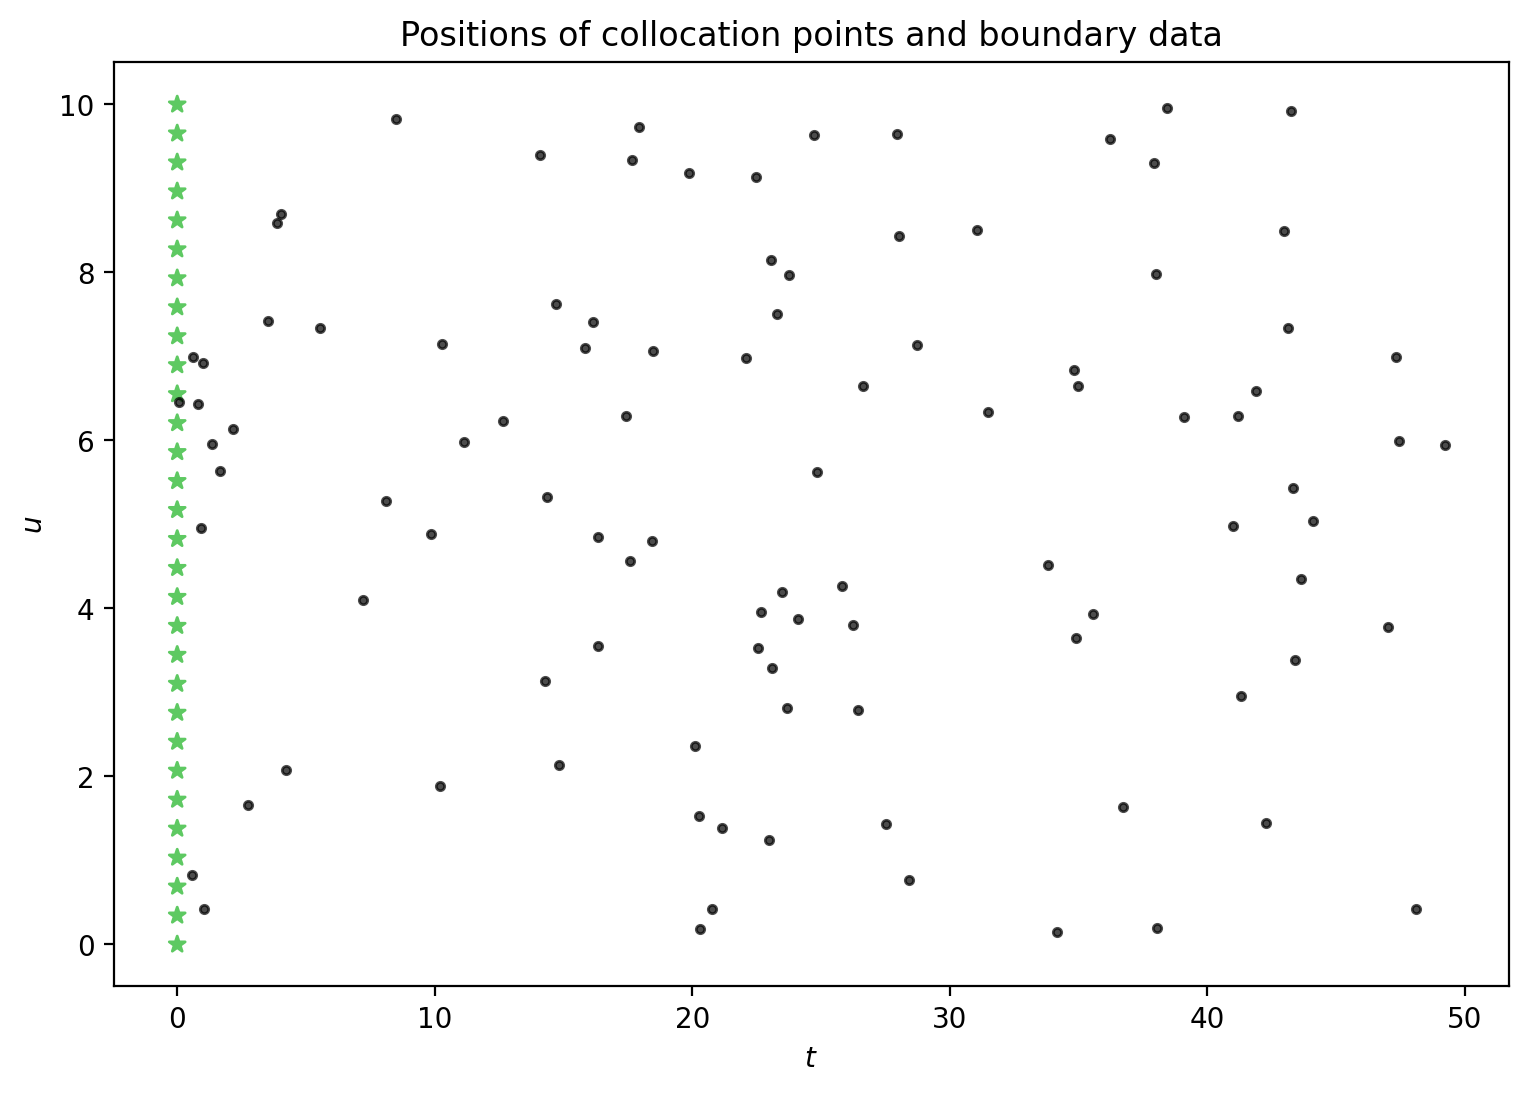

In [5]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
fig = plt.figure(figsize=(9,6))
plt.scatter(t_0, x_0, c=u_0, marker='*', vmin=-2, vmax=2)
#plt.scatter(t_b, x_b, c=u_b, marker='x', vmin=-2, vmax=2)
plt.scatter(t_r, x_r, c='black', marker='.', alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$u$')

plt.title('Positions of collocation points and boundary data');
plt.savefig('Xdata.png', bbox_inches='tight', dpi=300)

In [6]:
def init_model(num_hidden_layers=4, num_neurons_per_layer=8):
    
    # Initialize a feedforward neural network
    model = tf.keras.Sequential()

    # Input is two-dimensional (time + one spatial dimension)
    model.add(tf.keras.Input(2))

    # Introduce a scaling layer to map input to [lb, ub]
    scaling_layer = tf.keras.layers.Lambda(
                lambda x: (x - lb)/(ub - lb))
    model.add(scaling_layer)

    # Append hidden layers
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons_per_layer,
            activation=tf.keras.activations.get('tanh'),
            kernel_initializer='glorot_normal',kernel_regularizer=tf.keras.regularizers.L1L2(l1=0.01, l2=0.01)))


    # Output is one-dimensional
    model.add(tf.keras.layers.Dense(2))
    
    return model

In [7]:
def get_r(model, X_r):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape:
        # Split t and x to compute partial derivatives
        t, x = X_r[:, 0:1], X_r[:,1:2]

        # Variables t and x are watched during tape
        # to compute derivatives u_t and u_x
        tape.watch(t)
        tape.watch(x)

        # Determine residual 
        u = model(tf.stack([t[:,0], x[:,0]], axis=1))

        # Compute gradient u_x within the GradientTape
        # since we need second derivatives
        
        u_x1 = tape.gradient(u[:,0], x)
        u_x2 = tape.gradient(u[:,1], x)
        u_t1 = tape.gradient(u[:,0], t)
        u_t2 = tape.gradient(u[:,1], t)
        u_x = tf.concat([u_x1, u_x2], axis=1)
        u_t = tf.concat([u_t1, u_t2], axis=1)
        
        u_xx1 = tape.gradient(u_x[:,0], x)
        u_xx2 = tape.gradient(u_x[:,1], x)
        u_xt1 = tape.gradient(u_x[:,0], t)
        u_xt2 = tape.gradient(u_x[:,1], t)
        u_xx = tf.concat([u_xx1, u_xx2], axis=1)
        u_xt = tf.concat([u_xt1, u_xt2], axis=1)
  

    
    del tape

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xt)

In [8]:
def compute_loss(model, X_r, X_data, u_data):
    
    # Compute phi^r
    r = get_r(model, X_r)
    phi_r = tf.reduce_mean(tf.square(r))
    
    # Initialize loss
    loss = phi_r
    
    # Add phi^0 and phi^b to the loss
    for i in range(len(X_data)):
        u_pred = model(X_data[i])
        loss += tf.reduce_mean(tf.square(u_data[i] - u_pred))
    
    return loss

In [9]:
def get_grad(model, X_r, X_data, u_data):
    
    with tf.GradientTape(persistent=True) as tape:
        # This tape is for derivatives with
        # respect to trainable variables
        tape.watch(model.trainable_variables)
        loss = compute_loss(model, X_r, X_data, u_data)

    g = tape.gradient(loss, model.trainable_variables)
    del tape

    return loss, g

In [10]:
# Initialize model aka u_\theta
model = init_model()

# We choose a piecewise decay of the learning rate, i.e., the
# step size in the gradient descent type algorithm
# the first 1000 steps use a learning rate of 0.01
# from 1000 - 3000: learning rate = 0.001
# from 3000 onwards: learning rate = 0.0005

lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay([1000,3000],[1e-2,1e-3,5e-4])

# Choose the optimizer

optim = tf.keras.optimizers.Adam(learning_rate=lr)

loss_fn = tf.keras.losses.BinaryCrossentropy()

model.compile(optimizer=optim, loss=loss_fn)


In [11]:
# Define one training step as a TensorFlow function to increase speed of training
# @tf.function
def train_step():
    # Compute current loss and gradient w.r.t. parameters
    loss, grad_theta = get_grad(model, X_r, X_data, u_data)
    
    # Perform gradient descent step
    optim.apply_gradients(zip(grad_theta, model.trainable_variables))
    
    return loss

In [12]:
from time import time
warnings.filterwarnings("ignore")
# Number of training epochs
N = 50000
hist = []

# Start timer
t0 = time()

best_loss = float('inf')
best_weights = None
patience = 5 # 没有提升的训练轮数

for i in range(N+1):
    
    loss = train_step()
    
    # Append current loss to hist
    hist.append(loss.numpy())
    print('It = {:05d}| loss = {:10.8e}'.format(i,loss),'| progress report:' '%.2f%%' %(i/N*100))
#     if i%1000 == 0:
#         print('It = {:05d}| loss = {:10.8e}'.format(i,loss),'| progress report:' '%.2f%%' %(i/N*100))

    if loss < best_loss:
        best_loss = loss
        best_weights = model.get_weights()
        consecutive_epochs = 0
    else:
        consecutive_epochs += 1

    if consecutive_epochs >= patience:
        print("Validation loss did not improve for {} consecutive epochs, stopping training...".format(patience))
        break

# 恢复最好的模型参数
model.set_weights(best_weights)
        
# Print computation time
print('\nComputation time: {} seconds'.format(time()-t0))

It = 00000| loss = 1.80268783e+00 | progress report:0.00%
It = 00001| loss = 1.37515694e+00 | progress report:0.00%
It = 00002| loss = 1.04521595e+00 | progress report:0.00%
It = 00003| loss = 7.90698316e-01 | progress report:0.01%
It = 00004| loss = 5.91175897e-01 | progress report:0.01%
It = 00005| loss = 4.31491020e-01 | progress report:0.01%
It = 00006| loss = 3.00742986e-01 | progress report:0.01%
It = 00007| loss = 1.93037949e-01 | progress report:0.01%
It = 00008| loss = 1.07591405e-01 | progress report:0.02%
It = 00009| loss = 4.73188186e-02 | progress report:0.02%
It = 00010| loss = 1.60047524e-02 | progress report:0.02%
It = 00011| loss = 1.43408438e-02 | progress report:0.02%
It = 00012| loss = 3.59183416e-02 | progress report:0.02%
It = 00013| loss = 6.66590380e-02 | progress report:0.03%
It = 00014| loss = 9.11426613e-02 | progress report:0.03%
It = 00015| loss = 1.00480953e-01 | progress report:0.03%
It = 00016| loss = 9.40343972e-02 | progress report:0.03%
Validation los

### Plot solution

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Set up meshgrid
N = 100
tspace = np.array([1.0, 5.0, 10.0, 50.0])
xspace = np.array([0.0, 1.0, 5.0, 10.0])

T, X = np.meshgrid(tspace, xspace)
Xgrid = np.vstack([T.flatten(),X.flatten()]).T
print(Xgrid)
upred = model(tf.cast(Xgrid,DTYPE))


U = upred.numpy()
print(U)

y_pred = upred
y_pred_normalized = (y_pred - tf.reduce_min(y_pred)) / (tf.reduce_max(y_pred) - tf.reduce_min(y_pred))
U = y_pred_normalized.numpy()
print(U)



[[ 1.  0.]
 [ 5.  0.]
 [10.  0.]
 [50.  0.]
 [ 1.  1.]
 [ 5.  1.]
 [10.  1.]
 [50.  1.]
 [ 1.  5.]
 [ 5.  5.]
 [10.  5.]
 [50.  5.]
 [ 1. 10.]
 [ 5. 10.]
 [10. 10.]
 [50. 10.]]
[[0.90789318 0.94125099]
 [0.88732722 0.90043061]
 [0.86059811 0.84706929]
 [0.63976906 0.40821747]
 [0.96056647 1.00698789]
 [0.94173046 0.96911391]
 [0.91706614 0.9191612 ]
 [0.7050355  0.48748875]
 [1.12669083 1.20533471]
 [1.11447611 1.17933687]
 [1.09811159 1.14421484]
 [0.93766089 0.78802053]
 [1.24633734 1.32777282]
 [1.23943082 1.31158363]
 [1.23007531 1.28956317]
 [1.13041992 1.04707179]]
[[0.5433884  0.57966442]
 [0.52102329 0.53527299]
 [0.49195585 0.47724351]
 [0.25180821 0.        ]
 [0.60066966 0.65115213]
 [0.58018584 0.60996485]
 [0.55336383 0.55564217]
 [0.3227843  0.0862061 ]
 [0.78132693 0.86685074]
 [0.76804363 0.83857856]
 [0.75024751 0.80038397]
 [0.57576025 0.41302903]
 [0.91144037 1.        ]
 [0.90392965 0.98239454]
 [0.8937557  0.95844769]
 [0.78538225 0.69474264]]


In [14]:
tf.cast(Xpred,DTYPE)

NameError: name 'Xpred' is not defined

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Set up meshgrid
N = 100
tspace = np.linspace(0, ub[0], N + 1)
xspace = np.linspace(0, ub[1], N + 1)
surface = np.zeros((N+1, N+1))

T, X = np.meshgrid(tspace, xspace)
Xgrid = np.vstack([T.flatten(),X.flatten()]).T


upred = model(tf.cast(Xgrid,DTYPE))

U = upred.numpy().reshape(N+1,N+1,2)
for i, x in enumerate(xspace):
    for j, y in enumerate(tspace):
        surface[i][j] = phi(x, y)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
surf = ax.plot_surface(T, X, U,cmap='magma');
ax.view_init(15,-35)
ax.set_xlabel('$t$')
ax.set_ylabel('$u$')
ax.set_zlabel('$\\phi_\\theta(u,t)$')
fig.colorbar(surf, shrink=0.5, aspect=10)
